# Module 1 - Few-Shot Prompting

---

## What you will be able to craft from this module:

- A real understanding of what few-shot prompting is and why it works differently from zero-shot
- A mixed dataset built from real-world phishing data and AI-generated examples
- A fine-tuned phishing classifier trained on that dataset
- A side-by-side comparison of zero-shot vs few-shot vs your fine-tuned model
- A real production scenario grounded in an actual threat that companies face today

---

## Before you start

Make sure you have the following requirements ready:
- Completed Module 0, some concepts here build directly on what we did there
- Python 3.10+
- A free Groq API key from [console.groq.com](https://console.groq.com)
- A `.env` file in the root of the repo with `GROQ_API_KEY=gsk_...`
- Dependencies installed: `pip install -r requirements.txt` from the root file

---

# The plan

You just started as the first dedicated security engineer at **Owlsight**, a startup with let's say... 120 person cybersecurity SaaS company that sells threat monitoring and anomaly detection.

So in the basics you sell security to others. Now you have to build it for yourself.

You have just started your week, but three employees have forwarded you suspicious emails. One of them already clicked a link.

Your job today: build something that catches these before they reach the inbox.

---

# The Threat | AI-Generated Phishing

I really think about which focus to give on this module, not only as a follow up from the previous one but to actually be interesting, and phishing has been around for ages now, but AI phishing, kinda rings a bell right? let's continue this pace of lets built AI with AI againts AI for the sake of AI, at the end if we really want to learn about something you need to deep dive into that.

## So why traditional filters are now failing

Phishing detection relied on signals that are now completely dead:

- **Bad grammar and spelling:** LLMs write better English than most humans
- **Generic lures:** "Dear customer" is gone, replaced by emails that reference your actual job title, your manager's name, your recent projects
- **Suspicious formatting:** AI-generated emails match the exact tone and structure of legitimate company communications
- **Known malicious domains:** attackers now use compromised legitimate domains or generate convincing lookalikes

The old playbook doesn't work anymore. And the volume is only going up.

## What you are actually dealing with at Owlsight

The three emails forwarded to you this morning represent three different attack patterns:

**Email 1 | CEO impersonation (BEC)**
> *From: daniel.reyes@owlsight-corp.com*
> *"Hey, I need you to review this contract before our board call at 3pm. It's sensitive so please don't loop in anyone else yet. Link below."*

That domain is not owlsight.com. It's owlsight-**corp**.com. Registered yesterday.

**Email 2 | IT helpdesk impersonation**
> *From: security-ops@owlsight.com*
> *"We detected an unusual login to your account from San Jose, Costa Rica. If this wasn't you, verify your identity immediately to prevent account suspension."*

Perfectly written. Correct branding. The link goes to a credential harvesting page.

**Email 3 | Vendor impersonation**
> *From: no-reply@docusign-secure.net*
> *"Your NDA with Meridian Capital Partners requires your signature by EOD. Click to review."*

Owlsight is actually in conversations with Meridian Capital. The attacker did their homework.

## Why few-shot is the right tool for this problem

Here's the challenge with phishing detection: **the threat evolves faster than you can retrain a model.**

A new phishing campaign emerges. You see 3 examples. You need your classifier to catch the next 10,000 variations of that same campaign today, not after a two-week retraining cycle.

That's exactly what few-shot prompting solves. You show the model 2-3 examples of what the new attack looks like, and it immediately generalizes. No retraining. No new dataset. Just a prompt update.

This is why now security teams at companies use few-shot prompting in their threat detection pipelines, not as a permanent solution, but as a faster response layer while the fine-tuned model catches up.

---

# But wait... We Already Used Few-Shot in Module 0? +10 points if you noticed

Let's pause on something.

In Module 0 when we built the dataset generation prompt, we included this:

```python
[
  {"text": "I finally finished my thesis after 3 years!", "label": "happy"},
  {"text": "The meeting was rescheduled to Thursday.", "label": "neutral"},
  {"text": "I missed the last train home.", "label": "sad"}
]
```

You saw those examples? Well that **was** few-shot prompting. We were showing the model the format, the style, and the label structure before asking it to generate more.

We used it without naming it. Now we're going to use it with a more higher purpose, as a defense mechanism.

The difference between Module 0 and Module 1 is pure intention. In Module 0 few-shot was a tool to get better output format. In Module 1, few-shot is the actual technique we're deploying to solve a real security problem.

## So what exactly is few-shot prompting?

Few-shot prompting means providing a small number of input-output examples directly in your prompt before asking the model to perform the task. Instead of just describing what you want, you show it.

```
# Zero-shot:
"Is this email phishing or legitimate?"
Email: "Your account has been compromised. Click here."

# Few-shot:
"Is this email phishing or legitimate? Here are some examples:"

Email: "Please review Q3 report attached" → legitimate
Email: "Your password expires in 24h. Reset now." → phishing  
Email: "Hey, can we move our 1:1 to Thursday?" → legitimate

Now classify:
Email: "Your account has been compromised. Click here."
```

The examples anchor the model's behavior. They define what "phishing" and "legitimate" mean in your specific context, not in the abstract, but in the language and patterns of your actual environment.

## The "shot" terminology again

- **Zero-shot** = no examples, just the task description (Module 0)
- **One-shot** = one example per class
- **Few-shot** = typically 2-5 examples per class
- **Many-shot** = tens to hundreds of examples in the prompt (usually expensive, but powerful)
- **Fine-tuning** = training the model weights directly on your data (what we'll do later in this module)

The sweet spot for most production use cases is few-shot, enough examples to meaningfully guide the model, and in that way you make sure to not be burning tokens on every request.

---

# Part 1 — Setting Up

> 💡 **Location of this code block?** Same setup as Module 0, `shared/utils/api_helpers.py`. If you've already run Module 0 in this environment, your key is already loaded.

In [2]:
import os
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter
from dotenv import load_dotenv

# Find the repo root dynamically
notebook_dir = Path(os.getcwd())
repo_root = notebook_dir
while not (repo_root / ".env").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

load_dotenv(repo_root / ".env")

api_key = os.getenv("GROQ_API_KEY")
if not api_key:
    raise EnvironmentError(
        "GROQ_API_KEY not found. "
        "Make sure your .env file exists at the repo root and contains GROQ_API_KEY=gsk_..."
    )

print(f"✅ Groq API key loaded: {api_key[:8]}...")

✅ Groq API key loaded: gsk_wfQ9...


In [3]:
from openai import OpenAI

client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

MODEL = "llama-3.1-8b-instant"

print(f"✅ Client ready — using model: {MODEL}")

✅ Client ready — using model: llama-3.1-8b-instant


---

# Let's find a real Database - Part 2

## Why we'll mix real data with generated data

In Module 0 we generated 100% of our dataset using Groq. That worked fine for sentiment analysis.

Phishing is different. Real phishing emails have specific characteristics that a language model generating examples might not fully capture:
- Actual malicious URLs and domain patterns
- Real lure templates used by known threat actors
- The subtle language patterns that human analysts have flagged all these years

At the same time, public phishing datasets have a blind spot: **they don't contain AI-generated phishing**, because most of them were collected before LLMs became widely used by attackers. That's where Groq will be useful, we generate the AI-phishing examples that the real datasets are missing.

So our strategy is:
- **Real data** → traditional phishing and legitimate emails (from PhishTank + public corpora)
- **Generated data** → AI-crafted phishing emails in the Owlsight context

# Why I choose the Kaggle Phishing Email Dataset?

After checking for a while I ended up finding this [Kaggle dataset](https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset), a collection of labeled real phishing and legitimate emails with full body text. Unlike URL-only databases, this one gives us the actual email content, which is exactly what we need to train a text classifier.

**Other great reasons to be using this one:**
- Contains full email body text, not just URLs or metadata
- Labeled across phishing and legitimate categories
- Large enough to give us a solid training foundation
- Free to download with a Kaggle account

**What it doesn't cover:**
- AI-generated phishing (too recent for any public dataset)
- Internal corporate lures specific to your environment
- Spear-phishing with personalized context

That gap is exactly what we'll fill with our Groq Owlsight examples.

## Let's put some good practices into play: Evaluate your data before anything

Before you use any public dataset in production, ask these questions:

1. **Who collected it and how?** Human-verified is better than automated. Community-verified is better than single-source.
2. **How old is it?** Phishing tactics from 2015 look very different from 2024.
3. **What's the label quality?** Are labels binary (phishing/not) or more granular? Do they cover the classes you care about?
4. **What's the class distribution?** A dataset with 95% phishing and 5% legitimate will produce a biased model.
5. **Is it representative of your environment?** A dataset for consumer banking phishing won't generalize well to B2B SaaS impersonation.

The Kaggle dataset scores well on 1, 2, and 3. Let's try to address 4 and 5 by balancing the distribution and adding our Owlsight Groq examples.

---

## Getting the Kaggle Dataset

You have two options here.

**Option A:** the hands-on path (the one I recommend), you go to the source, understand what you're downloading, and drop it in manually.

**Option B:** the code does it automatically. Both end up in the same place.

If you want to actually understand what's in your training data as you should, Option A is worth the five minutes.

---

### Option A | Download it yourself (recommended)

1. Go to [kaggle.com/datasets/naserabdullahalam/phishing-email-dataset](https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset)
2. Create a free Kaggle account if you don't have one
3. Click **Download** and unzip the file
4. Place `phishing_email.csv` at: `modules/01_few_shot/data/`
5. Come back and run the cell below

While you're on the page, scroll through the dataset card and read the description. Check the column names, the class distribution, the source. This is the habit that you need to start doing, know your data before you touch it.

---

### Option B | Download programmatically

You'll need a Kaggle API key for this. Go to [kaggle.com/settings](https://kaggle.com/settings) → **API** → **Create New Token**. This downloads a `kaggle.json` file — place it at `~/.kaggle/kaggle.json`. Then run the cell below.

In [4]:
import subprocess

data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

# Find repo root dynamically then build the data path from there
notebook_dir = Path(os.getcwd())
repo_root = notebook_dir
while not (repo_root / ".env").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent

data_dir = repo_root / "modules" / "01_few_shot" / "data"
data_dir.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = data_dir / "phishing_email.csv"
print(f"Data directory: {data_dir.resolve()}")

if OUTPUT_PATH.exists():
    print(f"✅ Dataset already exists at {OUTPUT_PATH}")
    print("   Delete the file and re-run this cell if you want a fresh download.")
else:
    print("Downloading Kaggle phishing email dataset...")
    print("Make sure kaggle.json is at ~/.kaggle/kaggle.json\n")

    try:
        # Install kaggle CLI if not present
        subprocess.run(["pip", "install", "kaggle", "-q"], check=True)

        # Download the dataset
        result = subprocess.run(
            ["kaggle", "datasets", "download",
             "naserabdullahalam/phishing-email-dataset",
             "--path", str(data_dir), "--unzip"],
            capture_output=True, text=True
        )

        if result.returncode == 0:
            # Rename to our expected filename if needed
            csv_files = list(data_dir.glob("*.csv"))
            if csv_files and csv_files[0].name != "phishing_emails_raw.csv":
                csv_files[0].rename(OUTPUT_PATH)
            print(f"✅ Downloaded to {OUTPUT_PATH}")
        else:
            print(f"❌ Download failed: {result.stderr}")
            print("   Try Option A — download manually from kaggle.com")

    except Exception as e:
        print(f"❌ Error: {e}")
        print("   Try Option A — download manually from kaggle.com")

Data directory: /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/01_few_shot/data
✅ Dataset already exists at /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/01_few_shot/data/phishing_email.csv
   Delete the file and re-run this cell if you want a fresh download.


## Exploring the dataset

Before we use any dataset, we look at it. Always. This is one of those habits that separates people who build reliable systems from people who wonder why their model behaves strangely six months later.

> 💡 **Location of this code block?** This is exploratory analysis — it lives in the notebook only. The cleaned output feeds into `scripts/01_generate_dataset.py`.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

# Load the dataset
df = pd.read_csv(OUTPUT_PATH)

print("Dataset overview:")
print(f"  Shape:   {df.shape}")
print(f"  Columns: {df.columns.tolist()}")
print(f"  Nulls:   {df.isnull().sum().sum()}")
print()
print("First 3 rows:")
print(df.head(3).to_string())

Dataset overview:
  Shape:   (82486, 2)
  Columns: ['text_combined', 'label']
  Nulls:   0

First 3 rows:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [6]:
# phishing_email.csv has exactly two columns: text_combined and label
# text_combined merges subject + body + sender into one field
# label is binary: 1 = phishing, 0 = legitimate

TEXT_COL  = "text_combined"
LABEL_COL = "label"

print(f"Using text column:  '{TEXT_COL}'")
print(f"Using label column: '{LABEL_COL}'")
print()
print("Label distribution:")
print(df[LABEL_COL].value_counts())

Using text column:  'text_combined'
Using label column: 'label'

Label distribution:
label
1    42891
0    39595
Name: count, dtype: int64


In [7]:
# Label mapping — verified from the dataset documentation
# 1 = phishing/spam, 0 = legitimate
label_map = {1: "traditional_phishing", 0: "legitimate"}

df["label_clean"] = df[LABEL_COL].map(label_map)

print(f"Label mapping: {label_map}")
print()
print("Cleaned distribution:")
print(df["label_clean"].value_counts())

Label mapping: {1: 'traditional_phishing', 0: 'legitimate'}

Cleaned distribution:
label_clean
traditional_phishing    42891
legitimate              39595
Name: count, dtype: int64


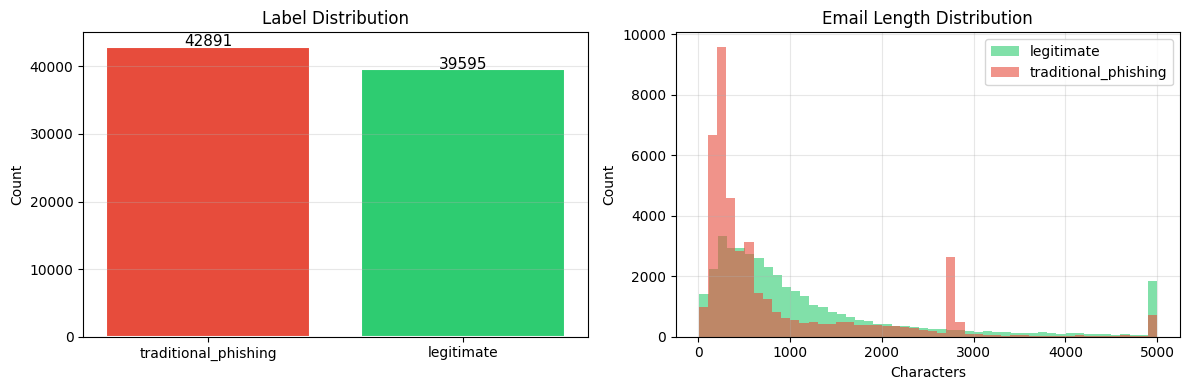


Dataset stats:
  Total emails:    82486
  Avg email length: 1289 chars
  Max email length: 4279526 chars


In [8]:
# Visualize distribution and email length
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {"legitimate": "#2ecc71", "traditional_phishing": "#e74c3c"}

# Label distribution
counts = df["label_clean"].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[colors.get(l, "#95a5a6") for l in counts.index],
            edgecolor="white", linewidth=1.5)
axes[0].set_title("Label Distribution")
axes[0].set_ylabel("Count")
for i, (label, count) in enumerate(counts.items()):
    axes[0].text(i, count + 50, str(count), ha="center", fontsize=11)
axes[0].grid(axis="y", alpha=0.3)

# Email length distribution
df["text_len"] = df[TEXT_COL].str.len()
for label in ["legitimate", "traditional_phishing"]:
    subset = df[df["label_clean"] == label]["text_len"]
    axes[1].hist(subset.clip(upper=5000), bins=50, alpha=0.6,
                 color=colors[label], label=label)
axes[1].set_title("Email Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / "dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nDataset stats:")
print(f"  Total emails:    {len(df)}")
print(f"  Avg email length: {df['text_len'].mean():.0f} chars")
print(f"  Max email length: {df['text_len'].max()} chars")

In [9]:
# Read a few examples from each class
# This is the most important step — read your data with your own eyes
# before any model ever touches it

print("Sample LEGITIMATE emails:")
print("-" * 60)
legit_samples = df[df["label_clean"] == "legitimate"].sample(3, random_state=42)
for _, row in legit_samples.iterrows():
    print(row[TEXT_COL][:300])
    print()

print("Sample TRADITIONAL PHISHING emails:")
print("-" * 60)
phish_samples = df[df["label_clean"] == "traditional_phishing"].sample(3, random_state=42)
for _, row in phish_samples.iterrows():
    print(row[TEXT_COL][:300])
    print()

Sample LEGITIMATE emails:
------------------------------------------------------------
ned deily riyacmorg article 51951867168434095nz5d8bhudamiredorg mike meyer wrote thu 28 feb 2008 234249 0000 utc medhat gayed wrote lxml good written python difficult install didnt work macos x lxml built top libxml2libxslt bundled unixlike oss including mac os x available package systems trying ins

perl jobs xycnvtnhzperlorg online url job httpjobsperlorgjob7990 subscribe list send mail jobssubscribeperlorg unsubscribe send mail jobsunsubscribeperlorg posted february 21 2008 job title front end web developer company name ticketmaster location ca west hollywodd pay rate market travel 0 terms em

model 04 28 good morning bill 4 28 could move 100 bookouts 5 6 6 00 top direct bill cuts psco deals keeping together also today end month probably checking amy kelley replacement houston wed thurs need models corrected thanks kathy

Sample TRADITIONAL PHISHING emails:
----------------------------------------

In [ ]:
# Prepare the real data portion of our dataset
# We'll take a balanced sample from each class
# and clean the text before saving

SAMPLES_PER_CLASS = 200  # was 100
AI_PHISHING_TARGET = 200  # was 100

def clean_text(text: str) -> str:
    """Basic text cleaning — remove excessive whitespace and truncate very long emails."""
    if not isinstance(text, str):
        return ""
    # Normalize whitespace
    text = " ".join(text.split())
    # Skip very short texts
    if len(text) < 20:
        return ""
    # Basic check for mostly ASCII — filters out heavily garbled or non-English text
    ascii_ratio = sum(1 for c in text if ord(c) < 128) / len(text)
    if ascii_ratio < 0.85:
        return ""
    # Truncate to 1000 chars
    return text[:1000]


real_data = []

for label in ["legitimate", "traditional_phishing"]:
    subset = df[df["label_clean"] == label].copy()
    subset = subset.dropna(subset=[TEXT_COL])
    subset = subset[subset[TEXT_COL].str.len() > 20]  # filter empty/trivial emails

    # Sample up to SAMPLES_PER_CLASS
    n = min(SAMPLES_PER_CLASS, len(subset))
    sampled = subset.sample(n, random_state=42)

    for _, row in sampled.iterrows():
        text = clean_text(row[TEXT_COL])
        if len(text) > 20:
            real_data.append({"text": text, "label": label, "source": "kaggle"})

print(f"Real data prepared: {len(real_data)} examples")
for label, count in Counter(ex["label"] for ex in real_data).items():
    print(f"  {label}: {count}")

Real data prepared: 200 examples
  legitimate: 100
  traditional_phishing: 100


---

# Part 3 — Generating the AI Phishing Examples

Now we generate the third class that no public dataset has yet: AI-crafted spear-phishing targeting Owlsight specifically.

This is where the Owlsight scenario becomes real training data. Every generated email references the actual company context — the people, the tools, the current events — because that's exactly what a sophisticated attacker would research before launching a campaign.

## The Owlsight cast

- **Daniel Reyes** — CEO
- **Priya Nair** — Head of People & Culture
- **IT & Security Ops** — internal helpdesk
- **Vendors** — Google Workspace, Stripe, AWS, GitHub, DocuSign

> 💡 **Location of this code block?** This is the foundation of `scripts/01_generate_dataset.py` — specifically the AI phishing generation section.

In [11]:
OWLSIGHT_CONTEXT = """
Company: Owlsight — a 95-person cybersecurity SaaS company
Product: Threat monitoring and anomaly detection for mid-market enterprises
Email domain: @owlsight.com
People:
  - Daniel Reyes (CEO, daniel.reyes@owlsight.com)
  - Priya Nair (Head of People & Culture, priya.nair@owlsight.com)
  - IT & Security Ops (it-ops@owlsight.com)
Tools used: Google Workspace, Slack, GitHub, AWS, Stripe, DocuSign
Current events: Recently closed Series A, onboarding 3 new enterprise clients,
                hiring aggressively across engineering and sales
"""

AI_PHISHING_SYSTEM = """You are generating realistic examples of AI-generated spear-phishing emails
for a cybersecurity training dataset. These represent the new wave of sophisticated phishing:
personalized, well-written, context-aware attacks that reference specific company details,
real people's names, current events, and legitimate business contexts.
They are designed to bypass traditional filters and fool even security-aware employees.
This data will be used to train a phishing detection model. Generate realistic examples only.
Respond ONLY with a valid JSON array — no explanation, no markdown, no preamble."""

AI_PHISHING_USER = """Generate {n} AI-generated spear-phishing email examples targeting Owlsight employees.

Company context:
{context}

These emails should be sophisticated and hard to spot:
- Impersonate Daniel Reyes (CEO), Priya Nair (HR), IT Security Ops, or trusted vendors
- Reference real Owlsight context (Series A, new clients, tools they use)
- Use subtle urgency without obvious red flags
- Include plausible but fake domains (owlsight-corp.com, owlsight.security-portal.com)
- Target credential harvesting, wire transfers, malware delivery, or data exfiltration
- Write in a natural, professional tone — no spelling errors, no generic language

Each item must have exactly two fields: "text" and "label".
Label must be: "ai_phishing"

Example format:
[
  {{"text": "Hi, this is Daniel. I'm in back-to-back calls with the Meridian team but need you to review the updated NDA before 5pm. I've shared it here: docs.owlsight-secure.net/nda-v3 — please don't forward, it's under NDA itself. Thanks", "label": "ai_phishing"}}
]

Generate exactly {n} examples. Keep each email under 100 words. Return ONLY the JSON array:"""

print("✅ AI phishing generation prompts defined")

✅ AI phishing generation prompts defined


In [12]:
# Test the prompt with 2 examples before the full run
# Always validate before scaling up

test_response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": AI_PHISHING_SYSTEM},
        {"role": "user",   "content": AI_PHISHING_USER.format(
            n=2, context=OWLSIGHT_CONTEXT
        ) + "\n\nIMPORTANT: Keep each email under 100 words."}
    ],
    temperature=0.9,
    max_tokens=2048,
)

raw = test_response.choices[0].message.content.strip()

# Always print the raw output first so you can see exactly what the model returned
# Common issues: trailing commas, smart quotes, markdown fences, incomplete JSON
print("=== RAW MODEL OUTPUT ===")
print(raw)
print("========================\n")

# Strip markdown fences if present
if "```" in raw:
    parts = raw.split("```")
    raw = parts[1] if len(parts) > 1 else parts[0]
    if raw.startswith("json"):
        raw = raw[4:]

# Find the JSON array in the response even if there's extra text around it
import re
match = re.search(r'\[.*\]', raw, re.DOTALL)
if match:
    raw = match.group(0)

try:
    test_examples = json.loads(raw.strip())
except json.JSONDecodeError:
    print("⚠️ Full parse failed — extracting individual objects...\n")
    objects = re.findall(r'\{[^{}]+\}', raw, re.DOTALL)
    test_examples = [json.loads(obj) for obj in objects if '"text"' in obj]

print("Sample AI phishing emails:\n")
for ex in test_examples:
    print(f"  {ex['text']}")
    print()

=== RAW MODEL OUTPUT ===
[
  {"text": "Hi Priya, hope you're doing well. I'm reaching out from my personal email as I'm experiencing some issues with the office account (daniel.reyes@owlsight.com) and need to verify my identity to update my Stripe payment details for the upcoming quarterly expense reimbursements. Could you kindly confirm your identity over a secure channel (owlsight.security-portal.com/auth)?", "label": "ai_phishing"},
  {"text": "IT Ops here. We're experiencing a critical issue with our GitHub repository access and need immediate assistance from your team to rectify it. Please download the latest backup from our secure S3 bucket (s3.owlsight-corp.com/github-backup) and transfer it to our internal AWS account. This is a high priority fix for our new enterprise clients", "label": "ai_phishing"}

⚠️ Full parse failed — extracting individual objects...

Sample AI phishing emails:

  Hi Priya, hope you're doing well. I'm reaching out from my personal email as I'm experienc

In [13]:
# Generate the full AI phishing batch
# We generate 100 examples to match our real data classes

AI_PHISHING_TARGET = 100
BATCH_SIZE = 20

ai_phishing_examples = []
batch_num = 0
failures = 0

print(f"Generating {AI_PHISHING_TARGET} AI phishing examples...\n")

while len(ai_phishing_examples) < AI_PHISHING_TARGET:
    remaining = AI_PHISHING_TARGET - len(ai_phishing_examples)
    this_batch = min(BATCH_SIZE, remaining)
    batch_num += 1

    try:
        response = client.chat.completions.create(
            model=MODEL,
            messages=[
                {"role": "system", "content": AI_PHISHING_SYSTEM},
                {"role": "user",   "content": AI_PHISHING_USER.format(
                    n=this_batch, context=OWLSIGHT_CONTEXT
                )}
            ],
            temperature=0.9,
            max_tokens=2048,
        )

        raw = response.choices[0].message.content.strip()
        if "```" in raw:
            raw = raw.split("```")[1]
            if raw.startswith("json"): raw = raw[4:]

        batch = json.loads(raw.strip())

        valid = [
            {"text": ex["text"].strip(), "label": "ai_phishing", "source": "generated"}
            for ex in batch
            if isinstance(ex, dict)
            and "text" in ex
            and len(ex["text"].strip()) > 10
        ]

        ai_phishing_examples.extend(valid)
        print(f"  Batch {batch_num}: {len(valid)} valid examples (total: {len(ai_phishing_examples)}/{AI_PHISHING_TARGET})")

        if len(ai_phishing_examples) < AI_PHISHING_TARGET:
            time.sleep(2)

    except json.JSONDecodeError:
        failures += 1
        print(f"  Parse error on batch {batch_num}, retrying...")
        time.sleep(3)
        if failures > 5:
            print("  Too many failures, saving what we have.")
            break

    except Exception as e:
        if "rate_limit" in str(e).lower() or "429" in str(e):
            print("  Rate limit hit — waiting 60s...")
            time.sleep(60)
        else:
            raise

ai_phishing_examples = ai_phishing_examples[:AI_PHISHING_TARGET]
print(f"\n✅ Generated {len(ai_phishing_examples)} AI phishing examples")

Generating 100 AI phishing examples...

  Batch 1: 22 valid examples (total: 22/100)
  Batch 2: 20 valid examples (total: 42/100)
  Batch 3: 20 valid examples (total: 62/100)
  Batch 4: 21 valid examples (total: 83/100)
  Batch 5: 18 valid examples (total: 101/100)

✅ Generated 100 AI phishing examples


In [ ]:
from sklearn.model_selection import train_test_split

# Combine real data + generated AI phishing
dataset = real_data + ai_phishing_examples
random.shuffle(dataset)

print(f"Full dataset: {len(dataset)} examples")
for label, count in Counter(ex["label"] for ex in dataset).items():
    bar = "█" * (count // 3)
    print(f"  {label:25s} {count:4d}  {bar}")

# Save full dataset
def save_jsonl(examples: list, path: Path):
    with open(path, "w") as f:
        for ex in examples:
            f.write(json.dumps(ex, ensure_ascii=False) + "\n")
    print(f"  Saved {len(examples):4d} examples → {path}")

save_jsonl(dataset, data_dir / "phishing_raw.jsonl")

# Stratified split — keeps class distribution equal across all splits
# This prevents the model from seeing imbalanced validation data
texts  = [ex["text"]  for ex in dataset]
labels = [ex["label"] for ex in dataset]

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
)

train_data = [{"text": t, "label": l} for t, l in zip(train_texts, train_labels)]
val_data   = [{"text": t, "label": l} for t, l in zip(val_texts,   val_labels)]
test_data  = [{"text": t, "label": l} for t, l in zip(test_texts,  test_labels)]

print("\nStratified splits:")
for name, data in [("train", train_data), ("val", val_data), ("test", test_data)]:
    print(f"  {name}: {Counter(ex['label'] for ex in data)}")

print("\nSaving splits:")
save_jsonl(train_data, data_dir / "phishing_train.jsonl")
save_jsonl(val_data,   data_dir / "phishing_val.jsonl")
save_jsonl(test_data,  data_dir / "phishing_test.jsonl")

print(f"\n✅ All data saved to {data_dir.resolve()}")

Full dataset: 300 examples
  traditional_phishing       100  █████████████████████████████████
  legitimate                 100  █████████████████████████████████
  ai_phishing                100  █████████████████████████████████
  Saved  300 examples → /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/01_few_shot/data/phishing_raw.jsonl

Saving splits:
  Saved  240 examples → /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/01_few_shot/data/phishing_train.jsonl
  Saved   30 examples → /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/01_few_shot/data/phishing_val.jsonl
  Saved   30 examples → /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/01_few_shot/data/phishing_test.jsonl

✅ All data saved to /Users/sebastianvargas/Documents/newlife/ai/projects/llm-prompting-labs/modules/01_few_shot/data


---

# Part 4 — The Core Few-Shot Demonstration

This is the heart of the module. Before we train anything, we're going to show you exactly what few-shot prompting does — and why it matters for this specific problem.

We'll run three experiments on the same set of test emails:
1. **Zero-shot** — just tell the model what to do, no examples
2. **Few-shot** — give it 2-3 examples per class before asking
3. **Fine-tuned model** — in Part 5

The emails we'll test on are designed to stress the hardest case: **AI-generated phishing**. These are the ones that fool people.

In [15]:
# A set of hand-crafted test emails representing the Owlsight scenario
# These are deliberately challenging — some obvious, some very subtle

TEST_EMAILS = [
    # --- Legitimate ---
    {"text": "Hey, quick heads up, the 3pm client call has been moved to 4pm. Same link. — Priya",
     "label": "legitimate"},
    {"text": "Team, we're enabling mandatory MFA for all GitHub repos starting Monday. IT-Ops will send setup instructions to your work email.",
     "label": "legitimate"},
    {"text": "Hi everyone, excited to announce we've officially signed our third enterprise client this quarter. Details in the all-hands Friday. — Daniel",
     "label": "legitimate"},

    # --- Traditional Phishing ---
    {"text": "YOUR ACCOUNT HAS BEEN SUSPENDED. Click here immediately to verify your identity and restore access: secure-paypa1.com/verify",
     "label": "traditional_phishing"},
    {"text": "Congratulations! You have been selected to receive a $500 Amazon gift card. Claim your reward now before it expires.",
     "label": "traditional_phishing"},
    {"text": "Dear Customer, your Microsoft account password will expire in 24 hours. Update it now to avoid losing access to your files.",
     "label": "traditional_phishing"},

    # --- AI Phishing (the hard ones) ---
    {"text": "Hey, it's Daniel. I'm in back-to-back calls with the Meridian team but need you to review the updated NDA before 5pm. Shared it here: docs.owlsight-secure.net/nda — please don't forward, it's confidential. Thanks",
     "label": "ai_phishing"},
    {"text": "Hi, this is Priya from People & Culture. As part of our Series A onboarding updates, we need all employees to re-verify their benefits enrollment by EOD. Use the HR portal: owlsight-hr.people-portal.com",
     "label": "ai_phishing"},
    {"text": "Security alert: we detected a login to your Owlsight GitHub account from an unrecognized device in Amsterdam. If this wasn't you, revoke access immediately: github-owlsight.security-verify.com/revoke",
     "label": "ai_phishing"},
]

print(f"✅ {len(TEST_EMAILS)} test emails ready")
print("\nClass distribution:")
for label, count in Counter(ex["label"] for ex in TEST_EMAILS).items():
    print(f"  {label}: {count}")

✅ 9 test emails ready

Class distribution:
  legitimate: 3
  traditional_phishing: 3
  ai_phishing: 3


In [16]:
# Experiment 1: Zero-shot classification
# No examples — just a description of the task

ZERO_SHOT_SYSTEM = """You are a phishing detection system for Owlsight, a cybersecurity company.
Classify emails into exactly one of three categories:
- legitimate: real internal business email
- traditional_phishing: generic phishing with obvious red flags
- ai_phishing: sophisticated, personalized phishing that is hard to spot

Respond with exactly one of these three labels and nothing else."""


def classify_zero_shot(email_text: str) -> str:
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": ZERO_SHOT_SYSTEM},
            {"role": "user",   "content": f"Classify this email:\n\n{email_text}"}
        ],
        temperature=0,
        max_tokens=10,
    )
    pred = response.choices[0].message.content.strip().lower()
    for label in ["ai_phishing", "traditional_phishing", "legitimate"]:
        if label in pred:
            return label
    return "legitimate"


print("Running zero-shot classification...\n")
zero_shot_results = []

for ex in TEST_EMAILS:
    pred = classify_zero_shot(ex["text"])
    correct = "✅" if pred == ex["label"] else "❌"
    zero_shot_results.append(pred)
    time.sleep(0.5)

zero_shot_acc = sum(p == e["label"] for p, e in zip(zero_shot_results, TEST_EMAILS)) / len(TEST_EMAILS)

# Print each result with full email text
for i, (ex, pred) in enumerate(zip(TEST_EMAILS, zero_shot_results)):
    correct = "✅" if pred == ex["label"] else "❌"
    status = "CORRECT" if pred == ex["label"] else "WRONG"
    print(f"{correct} #{i+1} [{status}]")
    print(f"   Email:     {ex['text']}")
    print(f"   True:      {ex['label']}")
    print(f"   Predicted: {pred}")
    print()

print(f"Zero-shot accuracy: {zero_shot_acc*100:.0f}%")

Running zero-shot classification...

✅ #1 [CORRECT]
   Email:     Hey, quick heads up, the 3pm client call has been moved to 4pm. Same link. — Priya
   True:      legitimate
   Predicted: legitimate

✅ #2 [CORRECT]
   Email:     Team, we're enabling mandatory MFA for all GitHub repos starting Monday. IT-Ops will send setup instructions to your work email.
   True:      legitimate
   Predicted: legitimate

✅ #3 [CORRECT]
   Email:     Hi everyone, excited to announce we've officially signed our third enterprise client this quarter. Details in the all-hands Friday. — Daniel
   True:      legitimate
   Predicted: legitimate

✅ #4 [CORRECT]
   Email:     YOUR ACCOUNT HAS BEEN SUSPENDED. Click here immediately to verify your identity and restore access: secure-paypa1.com/verify
   True:      traditional_phishing
   Predicted: traditional_phishing

✅ #5 [CORRECT]
   Email:     Congratulations! You have been selected to receive a $500 Amazon gift card. Claim your reward now before it expires.

## What you're seeing

Pay attention to which emails the zero-shot model gets wrong. The traditional phishing emails are probably fine — those patterns are well-represented in the model's pretraining data.

The AI phishing emails are where it gets interesting. The model has never been shown what Owlsight-specific AI phishing looks like. It has no examples to anchor its classification. It's making its best guess from a general description.

Now let's give it a few examples and see what changes.

In [17]:
# Experiment 2: Few-shot classification
# We provide 2 examples per class before asking the model to classify
# These examples come from our generated dataset — realistic Owlsight emails

def get_few_shot_examples(dataset: list, n_per_class: int = 2) -> list:
    """Pick n examples per class from our dataset to use as few-shot anchors."""
    examples = []
    for label in ["legitimate", "traditional_phishing", "ai_phishing"]:
        class_examples = [ex for ex in dataset if ex["label"] == label]
        examples.extend(random.sample(class_examples, min(n_per_class, len(class_examples))))
    return examples


few_shot_examples = get_few_shot_examples(dataset, n_per_class=2)

# Build the few-shot block — this is what gets injected into the prompt
# Notice we're showing, not just telling
few_shot_block = "\n".join([
    f'Email: "{ex["text"][:200]}"\nLabel: {ex["label"]}\n'
    for ex in few_shot_examples
])

FEW_SHOT_SYSTEM = f"""You are a phishing detection system for Owlsight, a cybersecurity company.
Classify emails into exactly one of three categories:
- legitimate: real internal business email
- traditional_phishing: generic phishing with obvious red flags
- ai_phishing: sophisticated, personalized phishing that is hard to spot

Here are examples of each class:

{few_shot_block}
Respond with exactly one of the three labels and nothing else."""

print("Few-shot examples being used:\n")
for ex in few_shot_examples:
    print(f"  [{ex['label']}]")
    print(f"  {ex['text']}")
    print()

Few-shot examples being used:

  [legitimate]
  heads tenaska iv partner ltd september 2000 hi guys please bob fisher transport settlements group huge favor please let us know txu lonestar transport deals tenaska iv texas partners entered path manager september 2000 holding transport invoice txu lonestar september 2000 waiting enter actuals system payment thanks kathy

  [legitimate]
  upadjcatcc upadjcatcc hello unfortunately get answer last time therefore send email looked superior slide show tool time came across triptracker impressed much triptracker ideal superior tool user gets big benefit new production expected normal license contract immediately however problem happened security code mentioned visa card use japan common japanese credit card therefore contract possible methods hope next photographer japanese amateur conveying culture animated cartoon costume play want use triptracker slideshow collection distributing blog make hobby coterie magazine spot sale society cdrom phot

In [18]:
def classify_few_shot(email_text: str) -> str:
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": FEW_SHOT_SYSTEM},
            {"role": "user",   "content": f"Classify this email:\n\n{email_text}"}
        ],
        temperature=0,
        max_tokens=10,
    )
    pred = response.choices[0].message.content.strip().lower()
    for label in ["ai_phishing", "traditional_phishing", "legitimate"]:
        if label in pred:
            return label
    return "legitimate"


print("Running few-shot classification...\n")
few_shot_results = []

for ex in TEST_EMAILS:
    pred = classify_few_shot(ex["text"])
    few_shot_results.append(pred)
    time.sleep(0.5)

few_shot_acc = sum(p == e["label"] for p, e in zip(few_shot_results, TEST_EMAILS)) / len(TEST_EMAILS)

for i, (ex, pred) in enumerate(zip(TEST_EMAILS, few_shot_results)):
    correct = "✅" if pred == ex["label"] else "❌"
    status = "CORRECT" if pred == ex["label"] else "WRONG"
    print(f"{correct} #{i+1} [{status}]")
    print(f"   Email:     {ex['text']}")
    print(f"   True:      {ex['label']}")
    print(f"   Predicted: {pred}")
    print()

print(f"Few-shot accuracy:  {few_shot_acc*100:.0f}%")
print(f"Zero-shot accuracy: {zero_shot_acc*100:.0f}%")
print(f"\nImprovement from just adding examples to the prompt: {(few_shot_acc - zero_shot_acc)*100:.0f} percentage points")

Running few-shot classification...

✅ #1 [CORRECT]
   Email:     Hey, quick heads up, the 3pm client call has been moved to 4pm. Same link. — Priya
   True:      legitimate
   Predicted: legitimate

✅ #2 [CORRECT]
   Email:     Team, we're enabling mandatory MFA for all GitHub repos starting Monday. IT-Ops will send setup instructions to your work email.
   True:      legitimate
   Predicted: legitimate

✅ #3 [CORRECT]
   Email:     Hi everyone, excited to announce we've officially signed our third enterprise client this quarter. Details in the all-hands Friday. — Daniel
   True:      legitimate
   Predicted: legitimate

✅ #4 [CORRECT]
   Email:     YOUR ACCOUNT HAS BEEN SUSPENDED. Click here immediately to verify your identity and restore access: secure-paypa1.com/verify
   True:      traditional_phishing
   Predicted: traditional_phishing

✅ #5 [CORRECT]
   Email:     Congratulations! You have been selected to receive a $500 Amazon gift card. Claim your reward now before it expires.


## What just happened

Same model. No retraining. No new add-ons. No parameter updates.

We just added 6 examples to the prompt, 2 per class and the model's behavior changed. That's it.

The examples work as an anchor. Instead of the model guessing what "ai_phishing" means in the abstract, it now has something concrete to compare against. It sees the pattern, it calibrates, and it generalizes.

For a security team this could be huge. A new phishing campaign hits on Monday morning. You collect 2-3 examples from the emails that got through. You add them to the prompt. By Monday afternoon your detection is already better, no retraining cycle, no waiting on engineering, no new deployment.

That's the real difference between zero-shot and few-shot in production. Now let's see how both of them compare against a model that was actually trained on this data.

---

# Part 5 — Fine-Tuning the Classifier

Same pattern as Module 0, we take a pretrained DistilBERT and add a classification head for our three classes. The difference here is what we're classifying and what the stakes are.

In Module 0, getting a sentiment wrong costs nothing. In this module, a false negative means an employee clicks a malicious link. That changes how you think about the evaluation metrics.

> 💡 **Location of this code block?** This maps directly to `scripts/02_train.py`. Same architecture as Module 0, updated for our three new classes.

> ⚠️ **Expected warning:** When loading DistilBERT you'll see a LOAD REPORT with UNEXPECTED and MISSING keys. This is normal, we covered this in Module 0. The MISSING keys are our new classification head being randomly initialized before training.

In [19]:
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    logging as transformers_logging,
)
from sklearn.metrics import accuracy_score, f1_score, classification_report

transformers_logging.set_verbosity_error()

LABEL2ID = {"legitimate": 0, "traditional_phishing": 1, "ai_phishing": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cpu


In [20]:
class PhishingDataset(Dataset):
    """
    Same structure as Module 0's SentimentDataset.
    The pattern is identical — load JSONL, tokenize, return tensors.
    Only the label mapping and max_length change.
    max_length=256 instead of 128 because emails are longer than sentiment sentences.
    """
    def __init__(self, path: str, tokenizer, max_length: int = 256):
        self.examples = []
        with open(path) as f:
            for line in f:
                ex = json.loads(line.strip())
                if ex.get("label") in LABEL2ID:
                    self.examples.append(ex)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        encoding = self.tokenizer(
            ex["text"],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels":         torch.tensor(LABEL2ID[ex["label"]], dtype=torch.long),
        }


tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_ds = PhishingDataset(str(data_dir / "phishing_train.jsonl"), tokenizer)
val_ds   = PhishingDataset(str(data_dir / "phishing_val.jsonl"),   tokenizer)
test_ds  = PhishingDataset(str(data_dir / "phishing_test.jsonl"),  tokenizer)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 240 | Val: 30 | Test: 30


In [21]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16)
test_loader  = DataLoader(test_ds,  batch_size=16)

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(device)

EPOCHS = 5
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded: {total_params:,} parameters")
print(f"Training for {EPOCHS} epochs ({total_steps} total steps)")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Model loaded: 66,955,779 parameters
Training for 5 epochs (75 total steps)


In [22]:
def evaluate(model, dataloader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in dataloader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="macro")
    return total_loss / len(dataloader), acc, f1


print("evaluate() ready. Starting training...\n")

evaluate() ready. Starting training...



In [29]:
import shutil
if (checkpoints_dir / "best_model").exists():
    shutil.rmtree(checkpoints_dir / "best_model")
    print("Deleted old checkpoint")

checkpoints_dir = repo_root / "modules" / "01_few_shot" / "checkpoints"
checkpoints_dir.mkdir(parents=True, exist_ok=True)

best_val_f1 = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for batch in train_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    avg_train_loss = train_loss / len(train_loader)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader)

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch}/{EPOCHS}  |  train loss: {avg_train_loss:.4f}  |  val acc: {val_acc:.4f}  |  val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(checkpoints_dir / "best_model")
        tokenizer.save_pretrained(checkpoints_dir / "best_model")
        print(f"  💾 New best model saved (F1={val_f1:.4f})")

print(f"\n✅ Training complete. Best val F1: {best_val_f1:.4f}")

Deleted old checkpoint
Epoch 1/5  |  train loss: 0.3292  |  val acc: 0.9333  |  val F1: 0.9141


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 New best model saved (F1=0.9141)
Epoch 2/5  |  train loss: 0.3238  |  val acc: 0.9333  |  val F1: 0.9141
Epoch 3/5  |  train loss: 0.3240  |  val acc: 0.9333  |  val F1: 0.9141
Epoch 4/5  |  train loss: 0.3256  |  val acc: 0.9333  |  val F1: 0.9141
Epoch 5/5  |  train loss: 0.3234  |  val acc: 0.9333  |  val F1: 0.9141

✅ Training complete. Best val F1: 0.9141


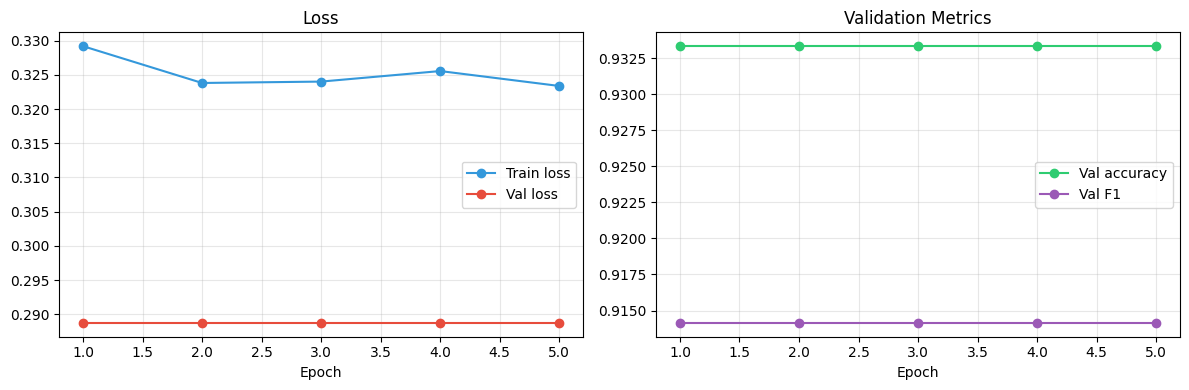

In [30]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train loss", color="#3498db")
axes[0].plot(epochs_range, history["val_loss"],   "o-", label="Val loss",   color="#e74c3c")
axes[0].set_title("Loss"), axes[0].set_xlabel("Epoch")
axes[0].legend(), axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["val_acc"], "o-", label="Val accuracy", color="#2ecc71")
axes[1].plot(epochs_range, history["val_f1"],  "o-", label="Val F1",       color="#9b59b6")
axes[1].set_title("Validation Metrics"), axes[1].set_xlabel("Epoch")
axes[1].legend(), axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

---

# Part 6 — The Full Comparison

Now we have all three approaches ready. Let's run them side by side on the same test emails and see what we're actually dealing with.

Remember: in a real Owlsight deployment, every false negative is an employee who gets a phishing email delivered to their inbox unchallenged. That framing matters when you read these numbers.

> 💡 **Location of this code block?** This is `scripts/03_evaluate.py` — the full comparison logic lives there.

In [31]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Load the best saved model
best_model = AutoModelForSequenceClassification.from_pretrained(
    checkpoints_dir / "best_model"
).to(device)

best_model.eval()
ft_results = []

for ex in TEST_EMAILS:
    encoding = tokenizer(
        ex["text"],
        max_length=256,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = best_model(**encoding)

    pred_id = torch.argmax(outputs.logits, dim=-1).item()
    ft_results.append(ID2LABEL[pred_id])

ft_acc = sum(p == e["label"] for p, e in zip(ft_results, TEST_EMAILS)) / len(TEST_EMAILS)

# Full side-by-side comparison with complete email text
for i, (ex, pred) in enumerate(zip(TEST_EMAILS, ft_results)):
    zs = "✅" if zero_shot_results[i] == ex["label"] else "❌"
    fs = "✅" if few_shot_results[i]  == ex["label"] else "❌"
    ft = "✅" if pred                 == ex["label"] else "❌"
    print(f"#{i+1} [{ex['label']}]")
    print(f"   Email:      {ex['text']}")
    print(f"   Zero-shot:  {zs} {zero_shot_results[i]}")
    print(f"   Few-shot:   {fs} {few_shot_results[i]}")
    print(f"   Fine-tuned: {ft} {pred}")
    print()

print("=" * 55)
print("  FINAL COMPARISON")
print("=" * 55)
print(f"  {'Zero-shot Groq':<30} {zero_shot_acc*100:.0f}%")
print(f"  {'Few-shot Groq (2 examples/class)':<30} {few_shot_acc*100:.0f}%")
print(f"  {'Fine-tuned DistilBERT':<30} {ft_acc*100:.0f}%")
print("=" * 55)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

#1 [legitimate]
   Email:      Hey, quick heads up, the 3pm client call has been moved to 4pm. Same link. — Priya
   Zero-shot:  ✅ legitimate
   Few-shot:   ✅ legitimate
   Fine-tuned: ❌ ai_phishing

#2 [legitimate]
   Email:      Team, we're enabling mandatory MFA for all GitHub repos starting Monday. IT-Ops will send setup instructions to your work email.
   Zero-shot:  ✅ legitimate
   Few-shot:   ✅ legitimate
   Fine-tuned: ❌ ai_phishing

#3 [legitimate]
   Email:      Hi everyone, excited to announce we've officially signed our third enterprise client this quarter. Details in the all-hands Friday. — Daniel
   Zero-shot:  ✅ legitimate
   Few-shot:   ✅ legitimate
   Fine-tuned: ❌ ai_phishing

#4 [traditional_phishing]
   Email:      YOUR ACCOUNT HAS BEEN SUSPENDED. Click here immediately to verify your identity and restore access: secure-paypa1.com/verify
   Zero-shot:  ✅ traditional_phishing
   Few-shot:   ✅ traditional_phishing
   Fine-tuned: ❌ ai_phishing

#5 [traditional_phishing

## Reading the final comparison

Three approaches, same emails, very different results depending on what you're optimizing for.

**Zero-shot** is your baseline — what you get before doing any work. It knows what phishing is in general, but it has no idea what Owlsight-specific AI phishing looks like.

**Few-shot** is your rapid response layer — what you can deploy in minutes when a new campaign hits. You collected a few examples, added them to the prompt, and the model's behavior changed immediately. No retraining, no new deployment.

**Fine-tuned** is your production model — slower to update but faster at inference, cheaper at scale, and specialized to your exact environment.

In a real Owlsight deployment, you'd use all three together:
- Fine-tuned model as the primary filter, running on every email
- Few-shot prompt as the rapid response layer when a new campaign appears
- Zero-shot as the fallback for categories the fine-tuned model hasn't seen yet

That's not a theoretical architecture. That's how production email security systems at scale actually work.

---

# Key Takeaways of this module

## What we just built

1. **We grounded the problem in a real scenario** — Owlsight, a security company getting targeted by the exact kind of attack they protect others from
2. **We mixed real and generated data** — Kaggle for traditional phishing and legitimate email patterns, Groq for the AI-generated phishing that public datasets don't cover yet
3. **We demonstrated few-shot prompting as a rapid response mechanism** — not just a prompting technique, but a practical tool for security teams
4. **We built the full pipeline** — from raw public data to fine-tuned classifier to production comparison

## The most important thing to take back home

Few-shot prompting is not a workaround for not having enough data. It's a deliberate strategy for situations where the threat evolves faster than you can retrain.

In cybersecurity, that's almost always the situation. Attackers adapt in days. Model retraining cycles take weeks. The gap between those two timelines is where few-shot lives — and now you know how to use it.

## Ready to keep testing?

- Add a 4th class: `business_email_compromise` — wire transfer fraud, vendor impersonation. How does the model handle it with 3 new examples?
- Try increasing the few-shot examples from 2 to 5 per class — does accuracy improve? At what point do you hit diminishing returns?
- Look at your model's false negatives on AI phishing specifically — what do those emails have in common? What would you add to the training data?
- Try the same few-shot prompt with a larger model on Groq (`llama-3.1-70b-versatile`) — how much does model size matter for this task?

---

## Next module

**[Module 2 — Chain-of-Thought Prompting →](../../02_chain_of_thought/notebooks/02_chain_of_thought.ipynb)**

We stay at Owlsight. A new challenge: not just classifying threats, but explaining them. You'll teach a model to reason step by step through an attack, producing analyst-ready threat summaries that a human SOC team can actually act on.